# Visualization

In [ ]:
import math
from itertools import combinations

import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TARGET = "health_condition"
ID_COL = "id"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="notebook")

## Load Data

In [15]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_submission = pd.read_csv("data/sample_submission.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Sample submission:", sample_submission.shape)

Train: (690088, 15)
Test: (295753, 14)
Sample submission: (295753, 2)


In [16]:
feature_cols = [col for col in train.columns if col not in [ID_COL, TARGET]]
numeric_cols = train[feature_cols].select_dtypes(include="number").columns.tolist()
categorical_cols = train[feature_cols].select_dtypes(exclude="number").columns.tolist()

plot_sample = train.sample(n=min(50_000, len(train)), random_state=RANDOM_STATE)
pairplot_sample = train.sample(n=min(5_000, len(train)), random_state=RANDOM_STATE)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical columns: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


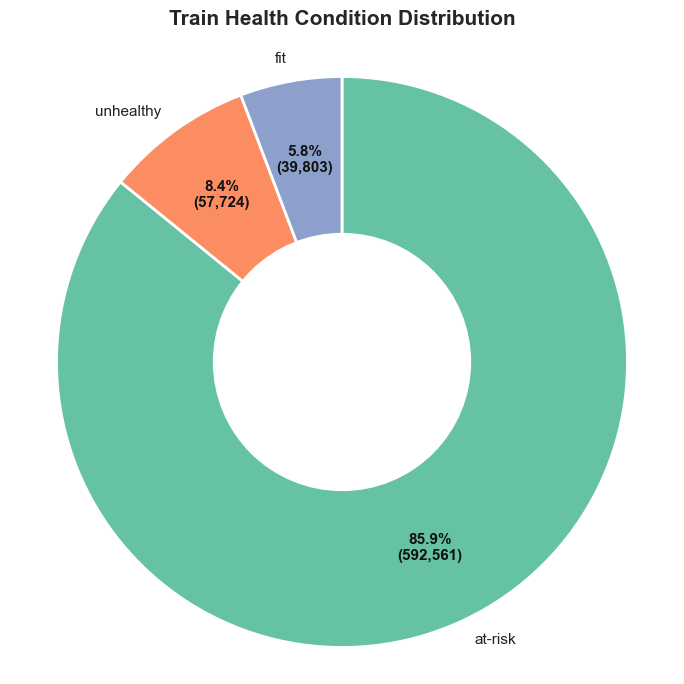

In [37]:
health_counts = train["health_condition"].value_counts()
colors = sns.color_palette("Set2", n_colors=len(health_counts))

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    health_counts.values,
    labels=health_counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct / 100 * health_counts.sum())):,})",
    startangle=90,
    counterclock=False,
    colors=colors,
    pctdistance=0.72,
    labeldistance=1.08,
    wedgeprops={"linewidth": 2, "edgecolor": "white"},
    textprops={"fontsize": 11, "color": "#222222"},
)

for autotext in autotexts:
    autotext.set_color("#111111")
    autotext.set_fontweight("bold")

centre_circle = plt.Circle((0, 0), 0.45, fc="white")
ax.add_artist(centre_circle)
ax.set_title("Train Health Condition Distribution", fontsize=15, fontweight="bold", pad=18)
ax.axis("equal")
plt.tight_layout()
plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'legend_title'

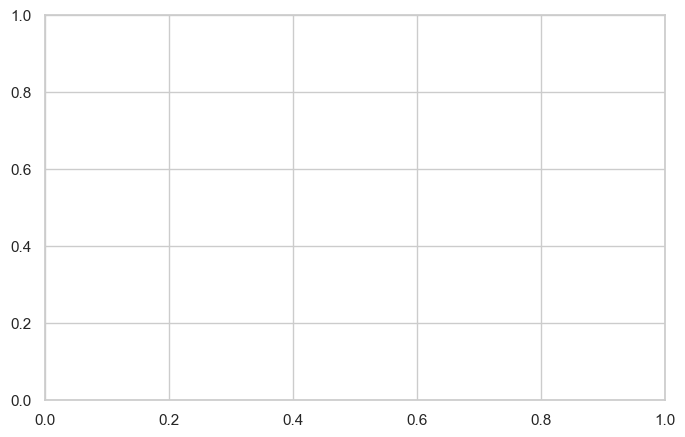

In [39]:
for col in train.columns:
    train.groupby(col)['health_condition'].value_counts(normalize=True).unstack().plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5),
        title=f"Health Condition Distribution by {col}",
        xlabel=col,
        ylabel="Proportion",
        legend_title="Health Condition",
    )